# Multiscale 1D RM-CLEAN

Standard (Hogbom) RM-CLEAN models the Faraday dispersion function (FDF) as a
sum of delta functions. That is a poor basis for **Faraday-thick** emission,
where the FDF is genuinely extended in Faraday depth: the clean model becomes
a picket fence of deltas that under-represents the integrated flux.

Multiscale RM-CLEAN (after Cornwell 2008 / Offringa & Smirnov 2017) instead
cleans with a set of extended kernels, so a thick component is modelled as one
broad feature. A uniform Faraday slab has an FDF that is a top-hat in $|P|$
with a *constant* complex phase, so a single complex amplitude times a real
scale kernel is the right model.

Here we build a thin + thick source, clean it both ways, and show that
multiscale (a) recovers the total polarised flux more accurately (debiased
moment 0) and (b) yields a compact model whose reverse RM-synthesis
reconstructs the observed $Q,U(\lambda^2)$ in band.

In [37]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from rm_lite.tools_1d import rmclean, rmsynth
from rm_lite.utils.logging import quiet_logs
from rm_lite.utils.multiscale import MultiscaleOptions
from rm_lite.utils.synthesis import freq_to_lambda2, inverse_rmsynth_nufft

import logging

plt.rcParams["figure.dpi"] = 150
rng = np.random.default_rng(42)

## A thin + thick source

A Burn slab of Faraday thickness $\Delta\phi$ has
$P(\lambda^2) = p\,e^{2i(\psi_0 + \phi_0\lambda^2)}\,\mathrm{sinc}(\Delta\phi\,\lambda^2)$; $\Delta\phi = 0$ is a thin source.
We sum a thin component at $\mathrm{RM}=-40$ and a thick slab
($\Delta\phi = 15$) at $\mathrm{RM}=+30$, then add noise to $Q$ and $U$.

In [38]:
def burn_slab(
    lambda_sq_arr_m2: NDArray[np.float64],
    frac_pol: float,
    psi0_deg: float,
    rm_radm2: float,
    delta_rm_radm2: float,
) -> NDArray[np.complex128]:
    """Burn slab P(lambda^2); delta_rm=0 is a Faraday-thin source."""
    return (
        frac_pol
        * np.exp(2j * (np.deg2rad(psi0_deg) + rm_radm2 * lambda_sq_arr_m2))
        * np.sinc(delta_rm_radm2 * lambda_sq_arr_m2 / np.pi)
    ).astype(np.complex128)


freq_arr_hz = np.linspace(0.8e9, 2.2e9, 400)
lambda_sq = freq_to_lambda2(freq_arr_hz)

thin = dict(frac_pol=0.2, psi0_deg=10, rm_radm2=-40, delta_rm_radm2=0.0)
thick = dict(frac_pol=0.5, psi0_deg=50, rm_radm2=30, delta_rm_radm2=30.0)
true_flux = thin['frac_pol'] + thick['frac_pol']

model = burn_slab(lambda_sq, **thin) + burn_slab(lambda_sq, **thick)

rms_noise = 0.02
complex_pol = (
    model
    + rng.normal(0, rms_noise, freq_arr_hz.size)
    + 1j * rng.normal(0, rms_noise, freq_arr_hz.size)
).astype(np.complex128)
complex_err = np.ones_like(complex_pol) * (rms_noise + 1j * rms_noise)

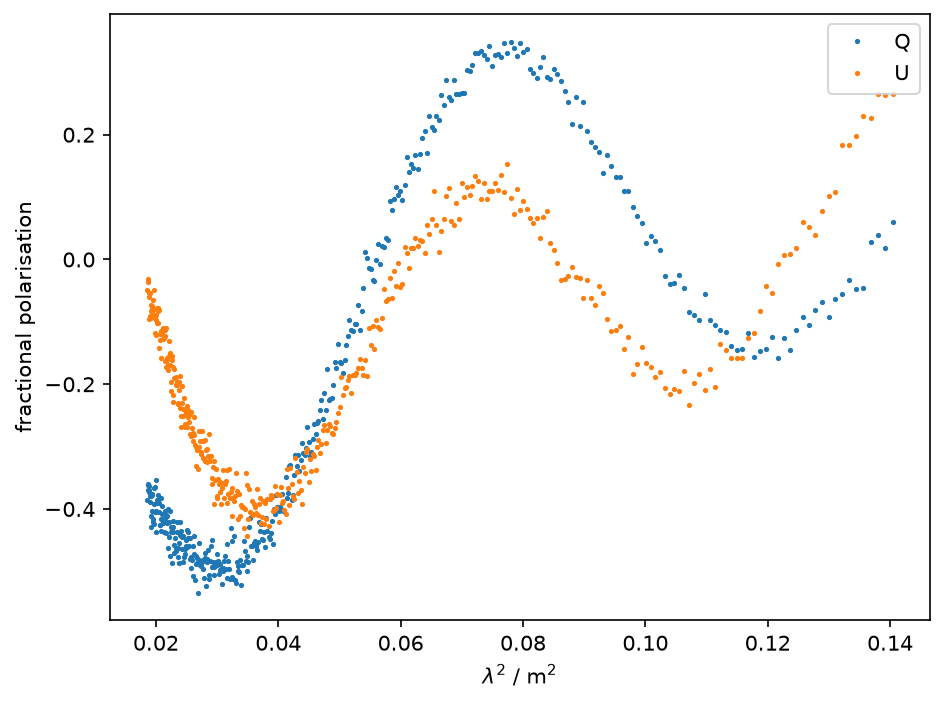

In [39]:
fig, ax = plt.subplots()
ax.plot(lambda_sq, complex_pol.real, '.', ms=3, label='Q')
ax.plot(lambda_sq, complex_pol.imag, '.', ms=3, label='U')
ax.set(xlabel=r'$\lambda^2$ / m$^2$', ylabel='fractional polarisation')
ax.legend()
fig.tight_layout()

## RM synthesis

Build the dirty FDF and RMSF.

In [40]:
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(
        freq_arr_hz, complex_pol, complex_err, n_samples=10, phi_max_radm2=300.0
    )

phi = synth.fdf_arrs['phi_arr_radm2'].to_numpy().astype(float)
dirty_fdf = synth.fdf_arrs['fdf_dirty_complex_arr'].to_numpy().astype(complex)
lam_sq_0 = float(synth.fdf_parameters['lam_sq_0_m2'][0])

## Clean, single-scale vs multiscale

The same call runs multiscale when `multiscale=True`; scales and kernel are
auto-selected (WSClean-style geometric set, tapered-quadratic kernel). The
same flag exists on `rmclean_3d_from_synth` for cubes.

In [41]:
with quiet_logs(logging.ERROR):
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=6, auto_threshold=1
    )
    multi = rmclean.run_rmclean_from_synth(
        synth, auto_mask=6, auto_threshold=1, multiscale=True,
        multiscale_options=MultiscaleOptions(max_iter_sub_minor=2000),
    )

n_iter_single = int(np.ravel(single.clean_parameters['n_iter'])[0])
n_iter_multi = int(np.ravel(multi.clean_parameters['n_iter'])[0])
print(f'components: single-scale {n_iter_single}, multiscale {n_iter_multi}')

components: single-scale 244, multiscale 9


## (a) Recovered polarised flux

The debiased moment 0 (`mom0_debias`) is the total polarised flux of the clean
FDF. The true integrated flux is the sum of the two components' fractional
polarisations. Multiscale lands closer to the truth, with far fewer
components.

In [42]:
mom0_single = float(single.fdf_parameters['mom0_debias'][0])
mom0_multi = float(multi.fdf_parameters['mom0_debias'][0])
print(f'true integrated flux : {true_flux:.3f}')
print(f'single-scale mom0    : {mom0_single:.3f}')
print(f'multiscale mom0      : {mom0_multi:.3f}')

# Multiscale recovers thick flux more accurately, with a far more compact model.
assert abs(mom0_multi - true_flux) < abs(mom0_single - true_flux)
assert 0.8 * true_flux < mom0_multi < 1.05 * true_flux
assert n_iter_multi < n_iter_single

true integrated flux : 0.700
single-scale mom0    : 0.594
multiscale mom0      : 0.653


## The clean FDFs

Single-scale scatters deltas across the thick slab; multiscale represents it
as one extended feature centred on the true slab, overlaid below as a
top-hat.

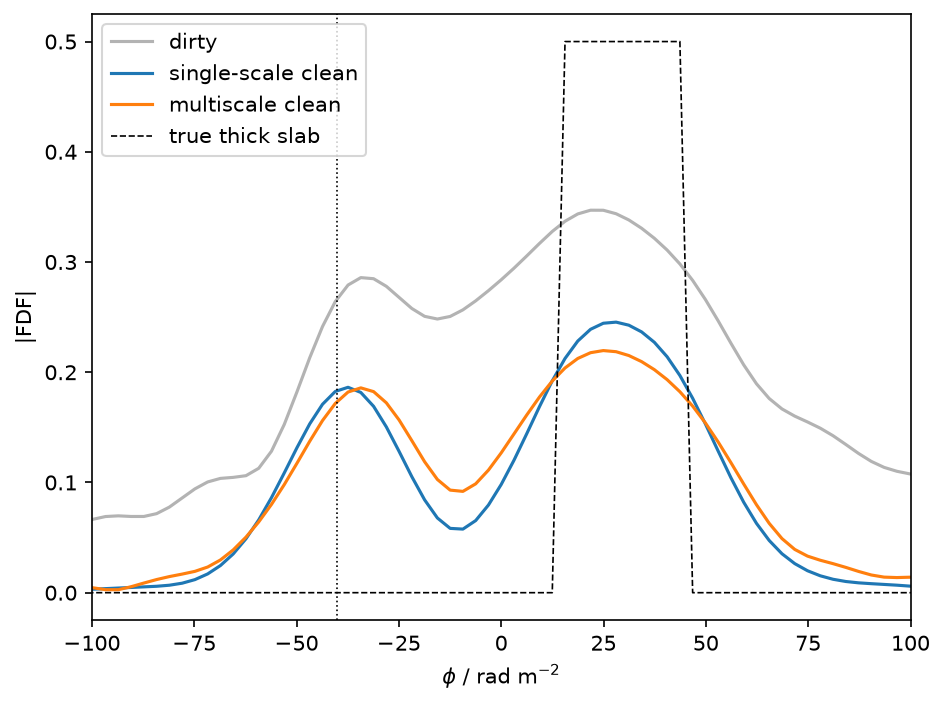

In [43]:
single_fdf = single.fdf_arrs['fdf_clean_complex_arr'].to_numpy().astype(complex)
multi_fdf = multi.fdf_arrs['fdf_clean_complex_arr'].to_numpy().astype(complex)

half = thick['delta_rm_radm2'] / 2
tophat = np.where(np.abs(phi - thick['rm_radm2']) <= half, thick['frac_pol'], 0.0)

fig, ax = plt.subplots()
ax.plot(phi, np.abs(dirty_fdf), color='0.7', label='dirty')
ax.plot(phi, np.abs(single_fdf), label='single-scale clean')
ax.plot(phi, np.abs(multi_fdf), label='multiscale clean')
ax.axvline(thin['rm_radm2'], ls=':', color='k', lw=0.8)
ax.plot(phi, tophat, ls='--', color='k', lw=0.8, label='true thick slab')
ax.set(xlabel=r'$\phi$ / rad m$^{-2}$', ylabel='|FDF|', xlim=(-100, 100))
ax.legend()
fig.tight_layout()

## (b) Reverse RM-synthesis to $\lambda^2$

Forward-modelling each clean model FDF back to $Q,U(\lambda^2)$ with
`inverse_rmsynth_nufft` checks the model reproduces the data. Both models
track the data in band; extrapolated to $\lambda^2 = 0$ (outside the band)
the thick component is unconstrained and the curves diverge from each other.

In [44]:
lambda_sq_ext = np.linspace(0.0, lambda_sq.max() * 1.05, 600)
model_ext = burn_slab(lambda_sq_ext, **thin) + burn_slab(lambda_sq_ext, **thick)
in_band = (lambda_sq_ext >= lambda_sq.min()) & (lambda_sq_ext <= lambda_sq.max())

recon = {}
for label, res in (('single-scale', single), ('multiscale', multi)):
    fdf_model = res.fdf_arrs['fdf_model_complex_arr'].to_numpy().astype(complex)
    recon[label] = inverse_rmsynth_nufft(fdf_model, lambda_sq_ext, phi, lam_sq_0)
    band_rms = float(np.sqrt(np.mean(
        np.abs(recon[label][in_band] - model_ext[in_band]) ** 2)))
    print(f'{label}: in-band reconstruction RMS = {band_rms:.4f}')
    assert band_rms < 4 * rms_noise

single-scale: in-band reconstruction RMS = 0.0087
multiscale: in-band reconstruction RMS = 0.0515


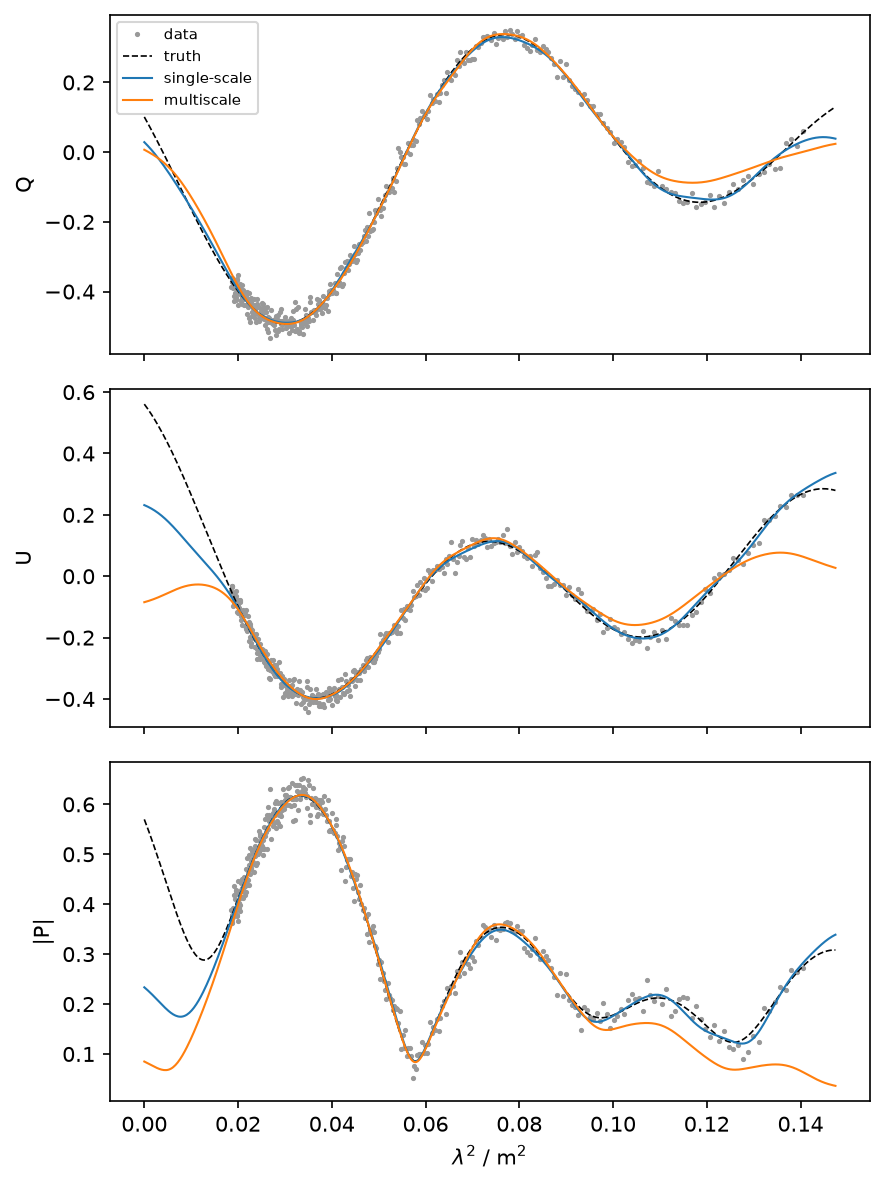

In [45]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(6, 8))
for ax, comp, lab in zip(
    axs, (np.real, np.imag, np.abs), ('Q', 'U', '|P|'), strict=True
):
    ax.plot(lambda_sq, comp(complex_pol), '.', ms=3, color='0.6', label='data')
    ax.plot(lambda_sq_ext, comp(model_ext), 'k--', lw=0.8, label='truth')
    for label in ('single-scale', 'multiscale'):
        ax.plot(lambda_sq_ext, comp(recon[label]), lw=1, label=label)
    ax.set(ylabel=lab)
axs[-1].set_xlabel(r'$\lambda^2$ / m$^2$')
axs[0].legend(fontsize=7)
fig.tight_layout()

## Summary

Multiscale RM-CLEAN recovers the Faraday-thick flux more accurately than
single-scale (closer debiased moment 0) using an order of magnitude fewer,
physically extended components, while still reconstructing the observed
$Q,U(\lambda^2)$ in band. Enable it with `multiscale=True` on
`run_rmclean_from_synth` (1D) or `rmclean_3d_from_synth` (3D), tuning
`MultiscaleOptions` (`scale_bias`, `scales`, `kernel`) as needed.